# 04 - Store Sales Forecasting - MLflow Experiment Tracking

## Objective

Track and compare forecasting experiments using MLflow.

Main goals:
- log baseline and improved model runs
- compare parameters, metrics and feature sets
- improve experiment reproducibility
- create a more professional ML workflow

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor

import mlflow
import mlflow.sklearn

sys.path.append(str(Path().resolve().parent))

from src.features import add_baseline_features, add_advanced_features, encode_family
from src.split import fixed_temporal_split
from src.metrics import (
    evaluate_regression,
    build_validation_results,
    compute_segment_metrics,
)
from src.tracking import (
    log_feature_list,
    log_feature_importance,
    log_run_context,
    log_validation_predictions,
)

In [2]:
SEED = 42
DATA_DIR = Path("../data")
USE_FULL_DATA = False
LAST_N_DAYS = 365

MLFLOW_EXPERIMENT_NAME = "store_sales_forecasting"
MLFLOW_TRACKING_URI = "file:../mlruns"

TRAIN_END = pd.Timestamp("2017-06-04")
VAL_START = pd.Timestamp("2017-06-05")
VAL_END = pd.Timestamp("2017-08-15")

print("Setup OK")
print("Data dir:", DATA_DIR.resolve())
print("MLflow tracking uri:", MLFLOW_TRACKING_URI)
print("Experiment name:", MLFLOW_EXPERIMENT_NAME)
print("Train end:", TRAIN_END)
print("Val range:", VAL_START, "->", VAL_END)

Setup OK
Data dir: /home/donatocorbacio/projects/store-sales-project/data
MLflow tracking uri: file:../mlruns
Experiment name: store_sales_forecasting
Train end: 2017-06-04 00:00:00
Val range: 2017-06-05 00:00:00 -> 2017-08-15 00:00:00


## MLflow setup

Configure local MLflow tracking and experiment name.

In [3]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print("Active experiment:", MLFLOW_EXPERIMENT_NAME)

Active experiment: store_sales_forecasting


## Load data

Load the Store Sales dataset and inspect the date range.

In [4]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train range:", train["date"].min(), "->", train["date"].max())
print("Test range:", test["date"].min(), "->", test["date"].max())

Train shape: (3000888, 6)
Test shape: (28512, 5)
Train range: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00


## Sorting

Sort by store, family and date to preserve temporal consistency.

In [5]:
train = train.sort_values(["store_nbr", "family", "date"]).copy()
test = test.sort_values(["store_nbr", "family", "date"]).copy()

print("Sorting completed.")
display(train.head())

Sorting completed.


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0


## Temporal subset

Use the last 365 days to keep experiments fast and consistent.

In [6]:
if not USE_FULL_DATA:
    cutoff = train["date"].max() - pd.Timedelta(days=LAST_N_DAYS)
    train = train[train["date"] >= cutoff].copy()

print("Train shape after subset:", train.shape)
print("New date range:", train["date"].min(), "->", train["date"].max())

Train shape after subset: (650430, 6)
New date range: 2016-08-15 00:00:00 -> 2017-08-15 00:00:00


## Base time features

Create the common time-based features used across experiments.

In [7]:
for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

display(train[["date", "year", "month", "day", "dayofweek", "weekofyear", "is_weekend"]].head())

,date,year,month,day,dayofweek,weekofyear,is_weekend
2350458,2016-08-15,2016,8,15,0,33,0
2352240,2016-08-16,2016,8,16,1,33,0
2354022,2016-08-17,2016,8,17,2,33,0
2355804,2016-08-18,2016,8,18,3,33,0
2357586,2016-08-19,2016,8,19,4,33,0


## Baseline Experiment (LGBM)

Reproduce the baseline model using lag features and track results with MLflow.

Key points:
- Feature set: lag_1, lag_7
- Fixed temporal split
- Evaluation: RMSLE + segment metrics

In [8]:
baseline_train = add_baseline_features(train)
baseline_train = baseline_train.dropna(subset=["lag_1", "lag_7"]).copy()

baseline_train, baseline_test, baseline_family_mapping = encode_family(baseline_train, test)

baseline_features = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "lag_1",
    "lag_7",
]

train_data_b, val_data_b, X_train_b, y_train_b, X_val_b, y_val_b = fixed_temporal_split(
    baseline_train,
    baseline_features,
    TRAIN_END,
    VAL_START,
    VAL_END,
)

print("Baseline train shape:", X_train_b.shape)
print("Baseline val shape:", X_val_b.shape)
print("Baseline train range:", train_data_b["date"].min(), "->", train_data_b["date"].max())
print("Baseline val range:", val_data_b["date"].min(), "->", val_data_b["date"].max())

Baseline train shape: (509652, 10)
Baseline val shape: (128304, 10)
Baseline train range: 2016-08-22 00:00:00 -> 2017-06-04 00:00:00
Baseline val range: 2017-06-05 00:00:00 -> 2017-08-15 00:00:00


In [9]:
baseline_params = {
    "model_type": "LGBMRegressor",
    "feature_set": "baseline_v1",
    "n_estimators": 200,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "random_state": SEED,
    "last_n_days": LAST_N_DAYS,
    "use_full_data": USE_FULL_DATA,
    "n_features": len(baseline_features),
}

with mlflow.start_run(run_name="lgbm_baseline_v1_fixed_split"):
    mlflow.set_tags({
        "project": "store_sales_forecasting",
        "notebook": "nb4",
        "model_family": "lightgbm",
        "experiment_type": "baseline",
        "validation_strategy": "fixed_temporal_holdout",
        "primary_metric": "rmsle",
    })

    mlflow.log_params(baseline_params)
    mlflow.log_param("train_end", str(TRAIN_END.date()))
    mlflow.log_param("val_start", str(VAL_START.date()))
    mlflow.log_param("val_end", str(VAL_END.date()))

    log_feature_list(baseline_features, "baseline_features.json")
    log_run_context(train_data_b, val_data_b, baseline_features, "baseline_v1", "baseline_run_context.json")

    baseline_model = LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        random_state=SEED,
        n_jobs=-1
    )

    baseline_model.fit(X_train_b, y_train_b)

    y_pred_b = baseline_model.predict(X_val_b)
    y_pred_b = np.clip(y_pred_b, 0, None)

    baseline_metrics = evaluate_regression(y_val_b, y_pred_b)
    mlflow.log_metrics(baseline_metrics)

    baseline_results = build_validation_results(val_data_b, y_pred_b)
    baseline_segment_metrics = compute_segment_metrics(baseline_results)
    mlflow.log_metrics(baseline_segment_metrics)

    log_validation_predictions(baseline_results, "baseline_validation_predictions.csv")

    baseline_importances = log_feature_importance(
        baseline_model,
        baseline_features,
        "baseline_feature_importance.png"
    )

    mlflow.sklearn.log_model(baseline_model, name="baseline_model")

    print("Baseline metrics:", baseline_metrics)
    print("Baseline segment metrics:", baseline_segment_metrics)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 924
[LightGBM] [Info] Number of data points in the train set: 509652, number of used features: 10
[LightGBM] [Info] Start training from score 472.846958


2026/04/23 15:10:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Baseline metrics: {'rmsle': 0.7823800132116003, 'mae': 67.39812010590542, 'rmse': 239.97491107773425, 'r2': 0.9662859503926585}
Baseline segment metrics: {'mae_weekday': 59.84358381953712, 'mae_weekend': 87.03991445046303}


## Advanced experiment

Recreate the NB3 feature set and track it with MLflow.

In [10]:
advanced_train = add_baseline_features(train)
advanced_train = add_advanced_features(advanced_train)
advanced_train = advanced_train.dropna().copy()

advanced_train, advanced_test, advanced_family_mapping = encode_family(advanced_train, test)

advanced_features = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "is_weekend",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14",
    "trend_1_7",
    "promo_last_7",
]

train_data_a, val_data_a, X_train_a, y_train_a, X_val_a, y_val_a = fixed_temporal_split(
    advanced_train,
    advanced_features,
    TRAIN_END,
    VAL_START,
    VAL_END,
)

print("Advanced train shape:", X_train_a.shape)
print("Advanced val shape:", X_val_a.shape)
print("Advanced train range:", train_data_a["date"].min(), "->", train_data_a["date"].max())
print("Advanced val range:", val_data_a["date"].min(), "->", val_data_a["date"].max())

Advanced train shape: (497178, 16)
Advanced val shape: (128304, 16)
Advanced train range: 2016-08-29 00:00:00 -> 2017-06-04 00:00:00
Advanced val range: 2017-06-05 00:00:00 -> 2017-08-15 00:00:00


In [11]:
advanced_params = {
    "model_type": "LGBMRegressor",
    "feature_set": "advanced_v1",
    "n_estimators": 300,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "random_state": SEED,
    "last_n_days": LAST_N_DAYS,
    "use_full_data": USE_FULL_DATA,
    "n_features": len(advanced_features),
}

with mlflow.start_run(run_name="lgbm_advanced_v1_fixed_split"):
    mlflow.set_tags({
        "project": "store_sales_forecasting",
        "notebook": "nb4",
        "model_family": "lightgbm",
        "experiment_type": "feature_engineering",
        "validation_strategy": "fixed_temporal_holdout",
        "primary_metric": "rmsle",
    })

    mlflow.log_params(advanced_params)
    mlflow.log_param("train_end", str(TRAIN_END.date()))
    mlflow.log_param("val_start", str(VAL_START.date()))
    mlflow.log_param("val_end", str(VAL_END.date()))

    log_feature_list(advanced_features, "advanced_features.json")
    log_run_context(
        train_data_a,
        val_data_a,
        advanced_features,
        "advanced_v1",
        "advanced_run_context.json",
    )

    advanced_model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=SEED,
        n_jobs=-1
    )

    advanced_model.fit(X_train_a, y_train_a)

    y_pred_a = advanced_model.predict(X_val_a)
    y_pred_a = np.clip(y_pred_a, 0, None)

    advanced_metrics = evaluate_regression(y_val_a, y_pred_a)
    mlflow.log_metrics(advanced_metrics)

    advanced_results = build_validation_results(val_data_a, y_pred_a)
    advanced_segment_metrics = compute_segment_metrics(advanced_results)
    mlflow.log_metrics(advanced_segment_metrics)

    log_validation_predictions(
        advanced_results,
        "advanced_validation_predictions.csv"
    )

    advanced_importances = log_feature_importance(
        advanced_model,
        advanced_features,
        "advanced_feature_importance.png"
    )

    mlflow.sklearn.log_model(advanced_model, name="advanced_model")

    print("Advanced metrics:", advanced_metrics)
    print("Advanced segment metrics:", advanced_segment_metrics)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 497178, number of used features: 16
[LightGBM] [Info] Start training from score 474.852324


2026/04/23 15:10:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Advanced metrics: {'rmsle': 0.6801390821651003, 'mae': 64.58270878235552, 'rmse': 230.26205202678483, 'r2': 0.9689598376594408}
Advanced segment metrics: {'mae_weekday': 56.22744565486077, 'mae_weekend': 86.30639291384193}


### Training Range Consistency

The validation window is fixed and identical across all experiments
(2017-06-05 to 2017-08-15).

However, the training start date differs between baseline and advanced models.

This is expected because advanced features (rolling statistics and promotion windows)
require a longer historical context, which removes more initial rows after feature engineering.

As a result:
- the baseline model can use more training data
- the advanced model starts later due to feature warmup requirements

This does not affect the fairness of the comparison, since both models are evaluated
on the same fixed temporal validation window.

This aspect should be considered when interpreting model improvements.

## Compare experiments

Compare baseline and advanced model performance.

In [12]:
comparison = pd.DataFrame([
    {
        "model": "LGBM Baseline v1",
        **baseline_metrics,
        **baseline_segment_metrics,
    },
    {
        "model": "LGBM Advanced v1",
        **advanced_metrics,
        **advanced_segment_metrics,
    }
])

display(comparison)

,model,rmsle,mae,rmse,r2,mae_weekday,mae_weekend
0,LGBM Baseline v1,0.782380,67.398120,239.974911,0.966286,59.843584,87.039914
1,LGBM Advanced v1,0.680139,64.582709,230.262052,0.968960,56.227446,86.306393


In [13]:
improvement = {
    "rmsle_improvement": baseline_metrics["rmsle"] - advanced_metrics["rmsle"],
    "mae_improvement": baseline_metrics["mae"] - advanced_metrics["mae"],
    "rmse_improvement": baseline_metrics["rmse"] - advanced_metrics["rmse"],
    "r2_improvement": advanced_metrics["r2"] - baseline_metrics["r2"],
}

print("Improvement summary:")
for k, v in improvement.items():
    print(f"{k}: {v:.6f}")

Improvement summary:
rmsle_improvement: 0.102241
mae_improvement: 2.815411
rmse_improvement: 9.712859
r2_improvement: 0.002674


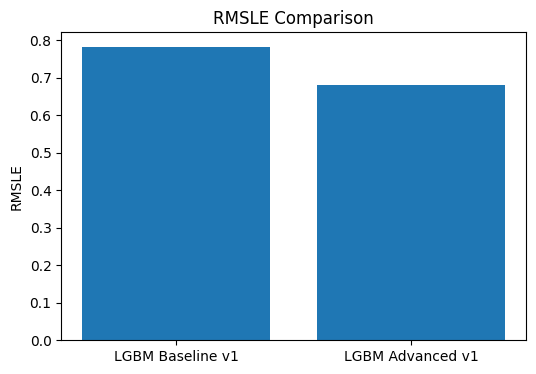

In [14]:
plt.figure(figsize=(6, 4))
plt.bar(comparison["model"], comparison["rmsle"])
plt.title("RMSLE Comparison")
plt.ylabel("RMSLE")
plt.show()

In [15]:
print("Baseline top importances:")
display(baseline_importances.head(10))

print("Advanced top importances:")
display(advanced_importances.head(10))

Baseline top importances:


day            1123
lag_1          1003
lag_7           978
onpromotion     705
dayofweek       669
weekofyear      557
store_nbr       520
month           224
family          178
year             43
dtype: int32

Advanced top importances:


day               1437
dayofweek          916
onpromotion        850
trend_1_7          806
lag_1              735
lag_7              731
weekofyear         709
store_nbr          653
promo_last_7       514
rolling_mean_7     435
dtype: int32

## Open MLflow UI

To inspect the experiment runs in the browser, run this command in the project root:

mlflow ui --backend-store-uri ./mlruns

## Conclusion

This notebook introduces MLflow into the forecasting workflow.

Main outcomes:
- baseline and advanced experiments are tracked consistently
- parameters, metrics and feature sets are logged
- advanced feature engineering can be compared directly against the baseline
- the project now follows a more professional experiment management workflow